# Participants in Derivatives Markets (Hull — Chapter 1)

In forward, futures, and options markets, Hull highlights three main types of traders:

1. **Hedgers**: aim to **reduce risk** (uncertainty about a future price).
2. **Speculators**: are willing to **take risk** to profit if their view is correct.
3. **Arbitrageurs**: seek a **risk-free profit** by exploiting a temporary inconsistency across markets.

We illustrate each type with a simple example (in the spirit of Chapter 1).

## 1) Hedgers: reducing risk

A hedger uses a forward/future/option to reduce exposure to an unfavorable price move.

- With a **forward**: you “lock in” a future price (less risk, but you also give up upside).
- With an **option**: you buy protection (insurance): you limit the downside while keeping upside potential.

In [1]:
import numpy as np

# Simplified "ImportCo" style example (Hull-like)
notional_gbp = 10_000_000        # £10m to pay
K = 1.2225                       # 3-month forward USD/GBP (locked-in price)

def cost_without_hedge(ST, notional):
    return ST * notional

def cost_with_forward(K, notional):
    return K * notional

ST_scenarios = [1.20, 1.30]      # two possible spot rates in 3 months

print("=== ImportCo (needs to pay GBP) ===")
for ST in ST_scenarios:
    print(f"S_T={ST:.4f} | No hedge: ${cost_without_hedge(ST, notional_gbp):,.0f} | With forward: ${cost_with_forward(K, notional_gbp):,.0f}")

=== ImportCo (needs to pay GBP) ===
S_T=1.2000 | No hedge: $12,000,000 | With forward: $12,225,000
S_T=1.3000 | No hedge: $13,000,000 | With forward: $12,225,000


**Interpretation:**
- If GBP **falls**, not hedging would have been better.
- If GBP **rises**, the hedge avoids a bad surprise.
Hedging does not guarantee a better outcome; it **reduces uncertainty**.

### Hedging with an option (insurance)

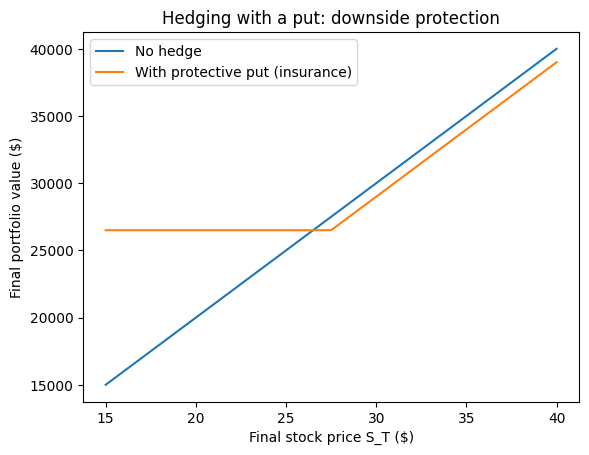

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Portfolio: 1000 shares, current price $28
n_shares = 1000
S0 = 28.0

# Protective put: strike 27.5, premium $1 per share (10 contracts * 100 = 1000 shares)
K = 27.5
premium = 1.0

S_T = np.linspace(15, 40, 300)

# Final value without hedge
value_no_hedge = n_shares * S_T

# Final value with hedge (put bought)
# If S_T < K: exercise => sell at K; otherwise keep shares at S_T.
value_with_put = n_shares * np.maximum(S_T, K) - n_shares * premium

plt.figure()
plt.plot(S_T, value_no_hedge, label="No hedge")
plt.plot(S_T, value_with_put, label="With protective put (insurance)")
plt.xlabel("Final stock price S_T ($)")
plt.ylabel("Final portfolio value ($)")
plt.title("Hedging with a put: downside protection")
plt.legend()
plt.show()

**How to read the graph:**
- With the put, the final value does not fall below a **floor** (minus the premium).
- In exchange, you pay an upfront **premium**.
Hull’s key idea: forward = “lock”, option = “insure”.

## 2) Speculators: taking risk (betting on prices)

A speculator accepts risk because they believe they have the correct market view.

Hull emphasizes two main ideas:
- **Futures** provide **leverage** (small initial cash via margin).
- **Options** also provide leverage, and if you BUY an option, the loss is limited to the premium.

In [3]:
# Hull-like example: speculator expects GBP to rise
notional_gbp = 250_000
F0 = 1.2223   # futures price (USD/GBP)
ST_up = 1.3000
ST_down = 1.2000

profit_futures_up = (ST_up - F0) * notional_gbp
profit_futures_down = (ST_down - F0) * notional_gbp

print("=== Futures speculation (long GBP) ===")
print(f"If S_T=1.3000 => profit = ${profit_futures_up:,.0f}")
print(f"If S_T=1.2000 => profit = ${profit_futures_down:,.0f}")

=== Futures speculation (long GBP) ===
If S_T=1.3000 => profit = $19,425
If S_T=1.2000 => profit = $-5,575


### Speculation with options (leverage + limited loss for the buyer)

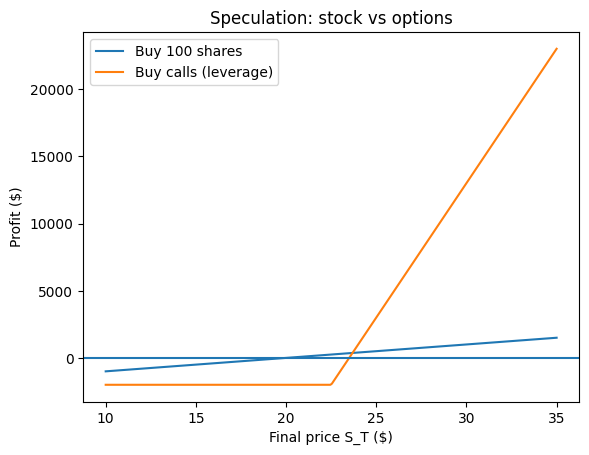

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Hull-like data
S0 = 20
budget = 2000

# Alternative 1: buy 100 shares
n_shares = 100
cost_shares = n_shares * S0

# Alternative 2: buy calls, strike 22.5, premium 1$ per option
K = 22.5
premium = 1.0
n_calls = 2000  # number of options (Hull-like), payoff per option = max(S_T-K,0)

S_T = np.linspace(10, 35, 300)

profit_shares = n_shares * (S_T - S0)
profit_calls = n_calls * np.maximum(S_T - K, 0) - n_calls * premium

plt.figure()
plt.plot(S_T, profit_shares, label="Buy 100 shares")
plt.plot(S_T, profit_calls, label="Buy calls (leverage)")
plt.axhline(0)
plt.xlabel("Final price S_T ($)")
plt.ylabel("Profit ($)")
plt.title("Speculation: stock vs options")
plt.legend()
plt.show()

**How to read the graph:**
- Calls amplify gains if the scenario is favorable (**leverage**).
- If the scenario is unfavorable, calls expire worthless: loss is limited to the **premium** (the amount invested).

## 3) Arbitrageurs: risk-free profit (when mispricing exists)

Arbitrage means entering multiple transactions simultaneously to lock in a **risk-free profit**.

Hull-style example: the same stock is quoted in two markets (New York in $ and London in £).
Convert the London price into USD using the FX rate:
- If the converted London price is higher, buy where it is cheaper and sell where it is more expensive.

In [5]:
# Hull-like example: stock at $120 in NY, £100 in London, FX = 1.23 $/£
price_ny_usd = 120
price_ldn_gbp = 100
fx_usd_per_gbp = 1.23

# London price converted to USD
price_ldn_usd = price_ldn_gbp * fx_usd_per_gbp

# Arbitrage on 100 shares
n = 100
profit = n * (price_ldn_usd - price_ny_usd)

print("=== Arbitrage (simple example) ===")
print(f"NY price: ${price_ny_usd}")
print(f"London price converted: ${price_ldn_usd:.2f}")
print(f"Potential profit on {n} shares (ignoring costs): ${profit:.0f}")

=== Arbitrage (simple example) ===
NY price: $120
London price converted: $123.00
Potential profit on 100 shares (ignoring costs): $300


**Why does arbitrage disappear quickly?**
Hull explains that these opportunities are short-lived: arbitrageurs buy where the asset is too cheap (pushing the price up) and sell where it is too expensive (pushing the price down), restoring price consistency.

## Conclusion (Chapter 1 level)

- **Hedgers**: reduce risk (forward = lock a price, option = insure).
- **Speculators**: take risk, often with **leverage** (futures/options).
- **Arbitrageurs**: exploit mispricing for **risk-free profit**, helping markets stay efficient.